In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

In [3]:
Nifty_50 = yf.download("^NSEI", start = "2015-01-01", end = "2026-09-01", auto_adjust = False)

[*********************100%***********************]  1 of 1 completed


In [4]:
print(Nifty_50.shape)

(2871, 6)


In [5]:
nifty = Nifty_50['Close']

In [6]:
return_df = np.log(nifty/nifty.shift(1))

In [7]:
return_df.dropna(inplace = True)

In [8]:
return_df

Ticker,^NSEI
Date,
2015-01-05,-0.002033
2015-01-06,-0.030422
2015-01-07,-0.003112
2015-01-08,0.016221
2015-01-09,0.006042
...,...
2026-08-25,0.004758
2026-08-26,-0.005224
2026-08-27,-0.004841


In [9]:
print(return_df.shape)

(2870, 1)


In [10]:
return_df.describe()

Ticker,^NSEI
count,2870.000000
mean,0.000367
std,0.010258
min,-0.139038
25%,-0.004359
50%,0.000551
75%,0.005844
max,0.084003


In [11]:
print(return_df.isnull().sum())

Ticker
^NSEI    0
dtype: int64


In [12]:
import matplotlib.pyplot as plt

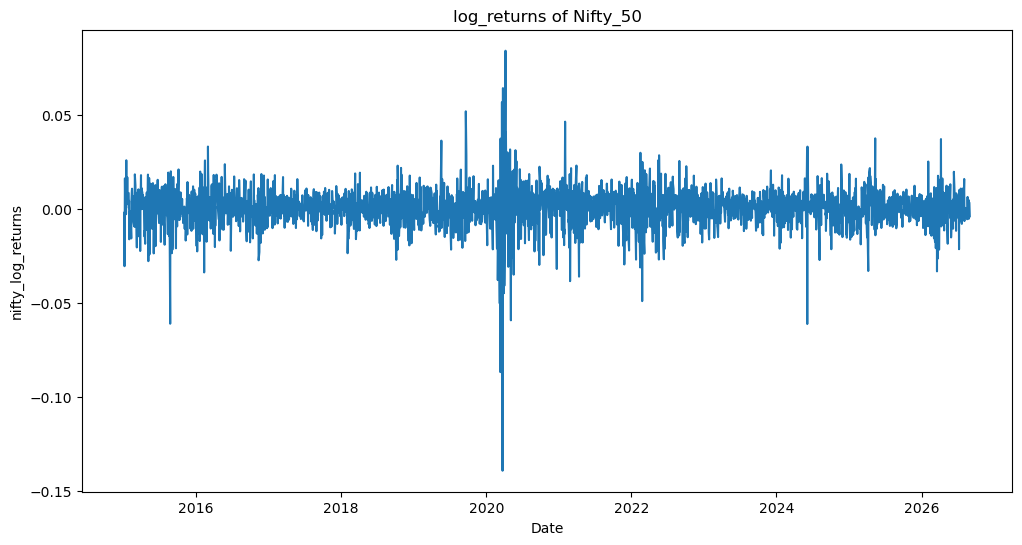

In [13]:

plt.figure(figsize = (12,6))
plt.title("log_returns of Nifty_50")
plt.xlabel("Date")
plt.ylabel("nifty_log_returns")
plt.plot(return_df)
plt.show()

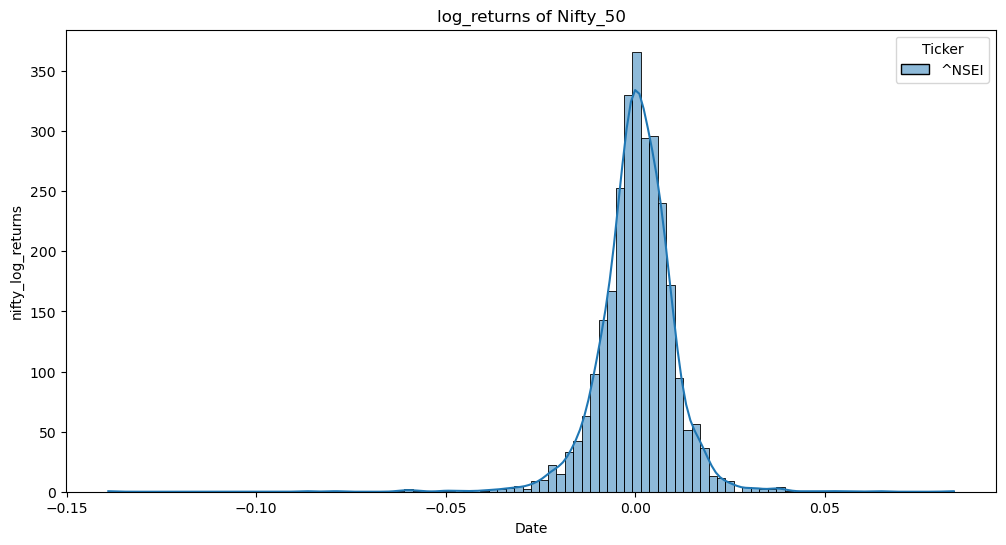

In [14]:
import seaborn as sns
plt.figure(figsize = (12,6))
plt.title("log_returns of Nifty_50")
plt.xlabel("Date")
plt.ylabel("nifty_log_returns")
sns.histplot(return_df, bins = 100, kde = True)
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
adf_result = adfuller(return_df)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -14.84541519669214
p-value: 1.8104593635503276e-27


In [17]:
if adf_result[1] < 0.05:
    print("The NIFTY 50 return series is stationary.")
else:
    print("The NIFTY 50 return series is non-stationary.")

The NIFTY 50 return series is stationary.


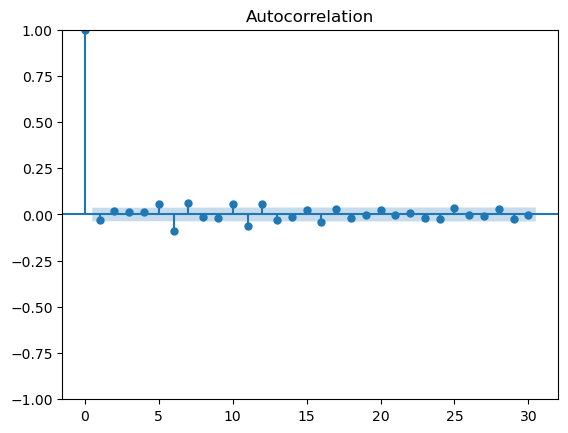

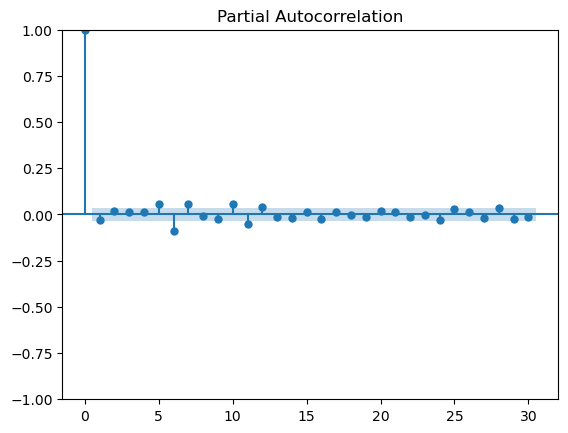

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(return_df, lags=30)
plt.show()

plot_pacf(return_df, lags=30)
plt.show()

In [19]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    return_df,
    lags=[10, 20, 30],
    return_df=True
)

print(ljung_box)

       lb_stat     lb_pvalue
10   60.199276  3.322831e-09
20   95.606773  7.634268e-12
30  106.034776  2.021717e-10


In [20]:
from statsmodels.tsa.arima.model import ARIMA

model_ar1 = ARIMA(
    return_df,
    order=(1, 0, 0)
)

result_ar1 = model_ar1.fit()

print(result_ar1.summary())

c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  ^NSEI   No. Observations:                 2870
Model:                 ARIMA(1, 0, 0)   Log Likelihood                9073.093
Date:                Wed, 07 Oct 2026   AIC                         -18140.185
Time:                        16:49:33   BIC                         -18122.299
Sample:                             0   HQIC                        -18133.737
                               - 2870                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.888      0.059   -1.39e-05       0.001
ar.L1         -0.0286      0.010     -2.828      0.005      -0.048      -0.009
sigma2         0.0001   1.07e-06     98.574      0.0

In [21]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

models = {
    "AR(1)": (1,0,0),
    "AR(2)": (2,0,0),
    "MA(1)": (0,0,1),
    "ARMA(1,1)": (1,0,1),
    "ARMA(2,1)": (2,0,1)
}

results = []

for name, order in models.items():
    model = ARIMA(return_df, order=order)
    result = model.fit()
    
    results.append([
        name,
        result.aic,
        result.bic
    ])

comparison = pd.DataFrame(
    results,
    columns=["Model", "AIC", "BIC"]
)

comparison = comparison.sort_values("AIC")

print(comparison)

c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

       Model           AIC           BIC
0      AR(1) -18140.185469 -18122.299267
2      MA(1) -18140.094558 -18122.208356
1      AR(2) -18139.113206 -18115.264936
3  ARMA(1,1) -18138.621032 -18114.772763
4  ARMA(2,1) -18138.362791 -18108.552454


In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = result.resid

print(acorr_ljungbox(
    resid,
    lags=[10, 20, 30],
    return_df=True
))

      lb_stat     lb_pvalue
10  50.400787  2.252202e-07
20  82.196736  1.658417e-09
30  92.424854  2.803980e-08


c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\arthi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


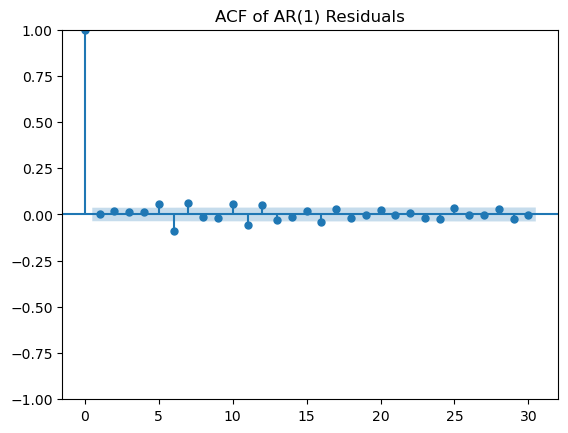

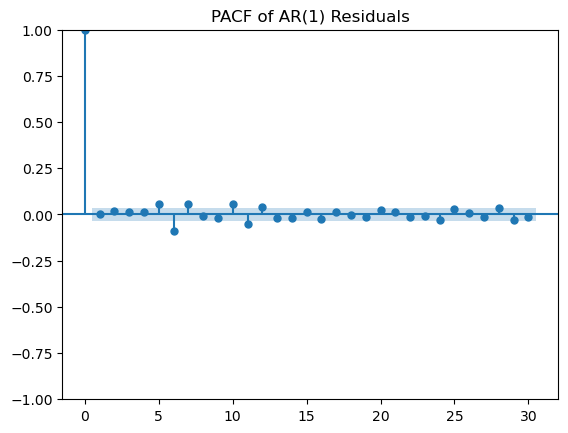

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
model_ar1 = ARIMA(
    return_df,
    order=(1, 0, 0)
)

result_ar1 = model_ar1.fit()
# AR(1) residuals
resid = result_ar1.resid

# ACF
plot_acf(resid, lags=30)
plt.title("ACF of AR(1) Residuals")
plt.show()

# PACF
plot_pacf(resid, lags=30)
plt.title("PACF of AR(1) Residuals")
plt.show()

In [24]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(resid, nlags=10)

print("LM Statistic:", arch_test[0])
print("LM p-value:", arch_test[1])
print("F Statistic:", arch_test[2])
print("F p-value:", arch_test[3])

LM Statistic: 740.9717462712744
LM p-value: 9.990945600748023e-153
F Statistic: 99.62248032380937
F p-value: 2.416022774761287e-177


In [25]:
from arch import arch_model

garch_model = arch_model(
    resid * 100,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(disp="off")

print(garch_result.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3676.81
Distribution:                  Normal   AIC:                           7359.62
Method:            Maximum Likelihood   BIC:                           7377.51
                                        No. Observations:                 2870
Date:                Wed, Oct 07 2026   Df Residuals:                     2870
Time:                        16:49:44   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0236  7.663e-03      3.077  2.091e-03 [8.

In [26]:
standardized_resid = garch_result.std_resid

In [27]:
from statsmodels.stats.diagnostic import het_arch

arch_after_garch = het_arch(
    standardized_resid.dropna(),
    nlags=10
)

print("LM Statistic:", arch_after_garch[0])
print("LM p-value:", arch_after_garch[1])
print("F Statistic:", arch_after_garch[2])
print("F p-value:", arch_after_garch[3])

LM Statistic: 11.657082277613345
LM p-value: 0.3086620030923297
F Statistic: 1.165977144194301
F p-value: 0.3090002614757107


In [28]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_garch = acorr_ljungbox(
    standardized_resid.dropna(),
    lags=[10, 20, 30],
    return_df=True
)

print(lb_garch)

      lb_stat  lb_pvalue
10  26.022510   0.003710
20  32.597916   0.037329
30  38.664497   0.133424


In [29]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_squared = acorr_ljungbox(
    standardized_resid.dropna() ** 2,
    lags=[10, 20, 30],
    return_df=True
)

print(lb_squared)

      lb_stat  lb_pvalue
10  10.542029   0.394292
20  16.591678   0.679306
30  25.765831   0.687028


In [33]:
historical_var_95 = return_df.quantile(0.05)
historical_var_99 = return_df.quantile(0.01)

print("95% Historical VaR:", historical_var_95)
print("99% Historical VaR:", historical_var_99)

95% Historical VaR: Ticker
^NSEI   -0.014976
Name: 0.05, dtype: float64
99% Historical VaR: Ticker
^NSEI   -0.026902
Name: 0.01, dtype: float64


In [34]:
mean_return = return_df.mean()
std_return = return_df.std()

print("Mean return:", mean_return)
print("Standard deviation:", std_return)

Mean return: Ticker
^NSEI    0.000367
dtype: float64
Standard deviation: Ticker
^NSEI    0.010258
dtype: float64


In [35]:
import scipy.stats as stats

mean_return = return_df.mean()
std_return = return_df.std()

z_95 = stats.norm.ppf(0.05)
z_99 = stats.norm.ppf(0.01)

parametric_var_95 = -(mean_return + z_95 * std_return)
parametric_var_99 = -(mean_return + z_99 * std_return)

print("95% Parametric VaR:", parametric_var_95)
print("99% Parametric VaR:", parametric_var_99)

95% Parametric VaR: Ticker
^NSEI    0.016506
dtype: float64
99% Parametric VaR: Ticker
^NSEI    0.023496
dtype: float64


In [36]:
import numpy as np

np.random.seed(42)

n_simulations = 10000

simulated_returns = np.random.normal(
    mean_return,
    std_return,
    n_simulations
)

monte_carlo_var_95 = -np.quantile(simulated_returns, 0.05)
monte_carlo_var_99 = -np.quantile(simulated_returns, 0.01)

print("95% Monte Carlo VaR:", monte_carlo_var_95)
print("99% Monte Carlo VaR:", monte_carlo_var_99)

95% Monte Carlo VaR: 0.016608126210216345
99% Monte Carlo VaR: 0.023436613059567853


In [39]:
forecast = garch_result.forecast(horizon=1)

variance_forecast = forecast.variance.iloc[-1, 0]

volatility_forecast = np.sqrt(variance_forecast)

print("Forecasted variance:", variance_forecast)
print("Forecasted volatility:", volatility_forecast)
resid * 100

Forecasted variance: 0.3512754003605842
Forecasted volatility: 0.5926849081599633


Date
2015-01-05   -0.239946
2015-01-06   -3.085716
2015-01-07   -0.435738
2015-01-08    1.575557
2015-01-09    0.612775
                ...   
2026-08-25    0.434179
2026-08-26   -0.546552
2026-08-27   -0.536695
2026-08-28    0.299861
2026-08-31   -0.422438
Length: 2870, dtype: float64

In [38]:
from scipy.stats import norm

z_95 = norm.ppf(0.05)
z_99 = norm.ppf(0.01)

garch_var_95 = -(mean_return * 100 + z_95 * volatility_forecast)
garch_var_99 = -(mean_return * 100 + z_99 * volatility_forecast)

print("95% GARCH-VaR:", garch_var_95, "%")
print("99% GARCH-VaR:", garch_var_99, "%")

95% GARCH-VaR: Ticker
^NSEI    0.938165
dtype: float64 %
99% GARCH-VaR: Ticker
^NSEI    1.342077
dtype: float64 %
